In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
import numpy as np

In [2]:
import pandas as pd
from pathlib import Path

base_dir = Path('data')

# train 2 years (2023-04 to 2025-03) to capture the multi-year trend
train_months = [f"2023-{m:02d}" for m in range(4, 13)] + \
               [f"2024-{m:02d}" for m in range(1, 13)] + \
               [f"2025-{m:02d}" for m in range(1, 4)]

# test on last 12 months (2025-04 to 2026-03)
test_months = [f"2025-{m:02d}" for m in range(4, 13)] + \
              [f"2026-{m:02d}" for m in range(1, 4)]

def load_data(months, path):
    dataframes = []
    for month_str in months:
        file_path = path / month_str / f"{month_str}-city-of-london-street.csv"
        if file_path.exists():
            dataframes.append(pd.read_csv(file_path))
        else:
            print(f"Warning: file not found at {file_path}")
            
    if dataframes:
        df = pd.concat(dataframes, ignore_index=True)
        return df, len(dataframes)
    return pd.DataFrame(), 0

#load data
train_df_raw, train_count = load_data(train_months, base_dir)
print(f"Loaded {train_count} train files. shape: {train_df_raw.shape}")

test_df_raw, test_count = load_data(test_months, base_dir)
print(f"Loaded {test_count} test files. shape: {test_df_raw.shape}")

Loaded 24 train files. shape: (19172, 12)
Loaded 12 test files. shape: (8923, 12)


In [3]:
#iterate/extract to get a list of all Crime types from training data
#using .dropna() ensures we don't include blank/NaN values in our list
crime_types = train_df_raw['Crime type'].dropna().unique().tolist()

print(f"Found {len(crime_types)} unique crime types:")
for crime in crime_types:
    print(f" - {crime}")

print("\n" + "="*50 + "\n")

#calculate the new dfs with the counts for both sets
train_df = train_df_raw.groupby(['Month', 'LSOA code', 'Crime type']).size().reset_index(name='Number of occurrences')
test_df = test_df_raw.groupby(['Month', 'LSOA code', 'Crime type']).size().reset_index(name='Number of occurrences')

#identify Top 5 LSOAs and split data 

#find the top 5 LSOAs by total crime volume in the training set
lsoa_totals = train_df.groupby('LSOA code')['Number of occurrences'].sum().sort_values(ascending=False)
top_5_lsoas = lsoa_totals.head(5).index.tolist()

print(f"Top 5 LSOAs by crime volume:\n{lsoa_totals.head(5)}\n")

#split train data
train_df_top5 = train_df[train_df['LSOA code'].isin(top_5_lsoas)].copy()
train_df_others = train_df[~train_df['LSOA code'].isin(top_5_lsoas)].copy()

#split test data
test_df_top5 = test_df[test_df['LSOA code'].isin(top_5_lsoas)].copy()
test_df_others = test_df[~test_df['LSOA code'].isin(top_5_lsoas)].copy()

print(f"train_df_top5 shape: {train_df_top5.shape} | train_df_others shape: {train_df_others.shape}")
print(f"test_df_top5 shape: {test_df_top5.shape} | test_df_others shape: {test_df_others.shape}\n")
print("--- Aggregated Train Data Head (Top 5) ---")
display(train_df_top5.head())

Found 14 unique crime types:
 - Other theft
 - Theft from the person
 - Bicycle theft
 - Burglary
 - Criminal damage and arson
 - Vehicle crime
 - Violence and sexual offences
 - Public order
 - Anti-social behaviour
 - Drugs
 - Shoplifting
 - Other crime
 - Possession of weapons
 - Robbery


Top 5 LSOAs by crime volume:
LSOA code
E01032739    12098
E01032740     1948
E01000005     1339
E01000002      747
E01000001      296
Name: Number of occurrences, dtype: int64

train_df_top5 shape: (1253, 4) | train_df_others shape: (786, 4)
test_df_top5 shape: (615, 4) | test_df_others shape: (431, 4)

--- Aggregated Train Data Head (Top 5) ---


,Month,LSOA code,Crime type,Number of occurrences
0,2023-04,E01000001,Bicycle theft,1
1,2023-04,E01000001,Burglary,1
2,2023-04,E01000001,Criminal damage and arson,1
3,2023-04,E01000001,Other theft,2
4,2023-04,E01000001,Theft from the person,3


In [4]:
print(f"Training rows (Top 5): {len(train_df_top5)} | (Others): {len(train_df_others)}")
print(f"Testing rows (Top 5): {len(test_df_top5)} | (Others): {len(test_df_others)}")

#helper function to engineer features
def prep_data(df):
    df = df.copy()
    df['Year'] = df['Month'].str[:4].astype(int)
    df['Month_Num'] = df['Month'].str[-2:].astype(int)
    # Time_Index captures the macro trend (continuous timeline since 2023)
    df['Time_Index'] = (df['Year'] - 2023) * 12 + df['Month_Num']
    return df

#applying feature engineering 
train_df_top5 = prep_data(train_df_top5)
test_df_top5 = prep_data(test_df_top5)
train_df_others = prep_data(train_df_others)
test_df_others = prep_data(test_df_others)

target = 'Number of occurrences'
#notice Time_Index 
features = ['Time_Index', 'Month_Num', 'LSOA code', 'Crime type']

X_train_top5 = train_df_top5[features].copy()
y_train_top5 = train_df_top5[target]
X_test_top5 = test_df_top5[features].copy()
y_test_top5 = test_df_top5[target]

X_train_others = train_df_others[features].copy()
y_train_others = train_df_others[target]
X_test_others = test_df_others[features].copy()
y_test_others = test_df_others[target]

categorical_cols = ['LSOA code', 'Crime type']
for col in categorical_cols:
    X_train_top5[col] = X_train_top5[col].astype('category')
    X_test_top5[col] = X_test_top5[col].astype(X_train_top5[col].dtype)
    
    X_train_others[col] = X_train_others[col].astype('category')
    X_test_others[col] = X_test_others[col].astype(X_train_others[col].dtype)

#initializing the XGBoost Regressors (we can see if giving different for both would yield better results)
xgb_params = {
    'n_estimators': 200,
    'max_depth': 6,
    'learning_rate': 0.1,
    'enable_categorical': True, 
    'tree_method': 'hist'       
}

model_top5 = xgb.XGBRegressor(**xgb_params)
model_others = xgb.XGBRegressor(**xgb_params)

#chatgpt pretty print
print("\nTraining the Top 5 LSOAs XGBoost model...")
model_top5.fit(X_train_top5, y_train_top5)

print("Training the Others LSOAs XGBoost model...")
model_others.fit(X_train_others, y_train_others)

print("Both models trained successfully!")

#test
pred_top5 = model_top5.predict(X_test_top5)
pred_others = model_others.predict(X_test_others)

#compute bias
bias_top5 = (pred_top5.sum() - y_test_top5.values.sum()) / y_test_top5.values.sum()
bias_others = (pred_others.sum() - y_test_others.values.sum()) / y_test_others.values.sum()

print(f"Bias (Top 5):   {bias_top5*100:.2f}%")
print(f"Bias (Others):  {bias_others*100:.2f}%")

#apply bias
pred_top5_corrected   = pred_top5   * (1 / (1 + bias_top5))
pred_others_corrected = pred_others * (1 / (1 + bias_others))

#build results_df 
results_top5 = test_df_top5.copy()
results_top5['Predicted Occurrences'] = pred_top5_corrected

results_others = test_df_others.copy()
results_others['Predicted Occurrences'] = pred_others_corrected

#combine and finalise 
results_df = pd.concat([results_top5, results_others], ignore_index=True)
results_df = results_df.rename(columns={'Number of occurrences': 'Actual Occurrences'})
results_df['Predicted Occurrences'] = results_df['Predicted Occurrences'].clip(lower=0).round()
results_df['Difference'] = results_df['Predicted Occurrences'] - results_df['Actual Occurrences']

print(f"\nresults_df shape: {results_df.shape}")
results_df.head()

Training rows (Top 5): 1253 | (Others): 786
Testing rows (Top 5): 615 | (Others): 431

Training the Top 5 LSOAs XGBoost model...
Training the Others LSOAs XGBoost model...
Both models trained successfully!
Bias (Top 5):   1.30%
Bias (Others):  11.74%

results_df shape: (1046, 9)


,Month,LSOA code,Crime type,Actual Occurrences,Year,Month_Num,Time_Index,Predicted Occurrences,Difference
0,2025-04,E01000001,Anti-social behaviour,2,2025,4,28,1.0,-1.0
1,2025-04,E01000001,Burglary,1,2025,4,28,1.0,0.0
2,2025-04,E01000001,Other theft,6,2025,4,28,3.0,-3.0
3,2025-04,E01000001,Public order,1,2025,4,28,0.0,-1.0
4,2025-04,E01000001,Robbery,1,2025,4,28,1.0,0.0


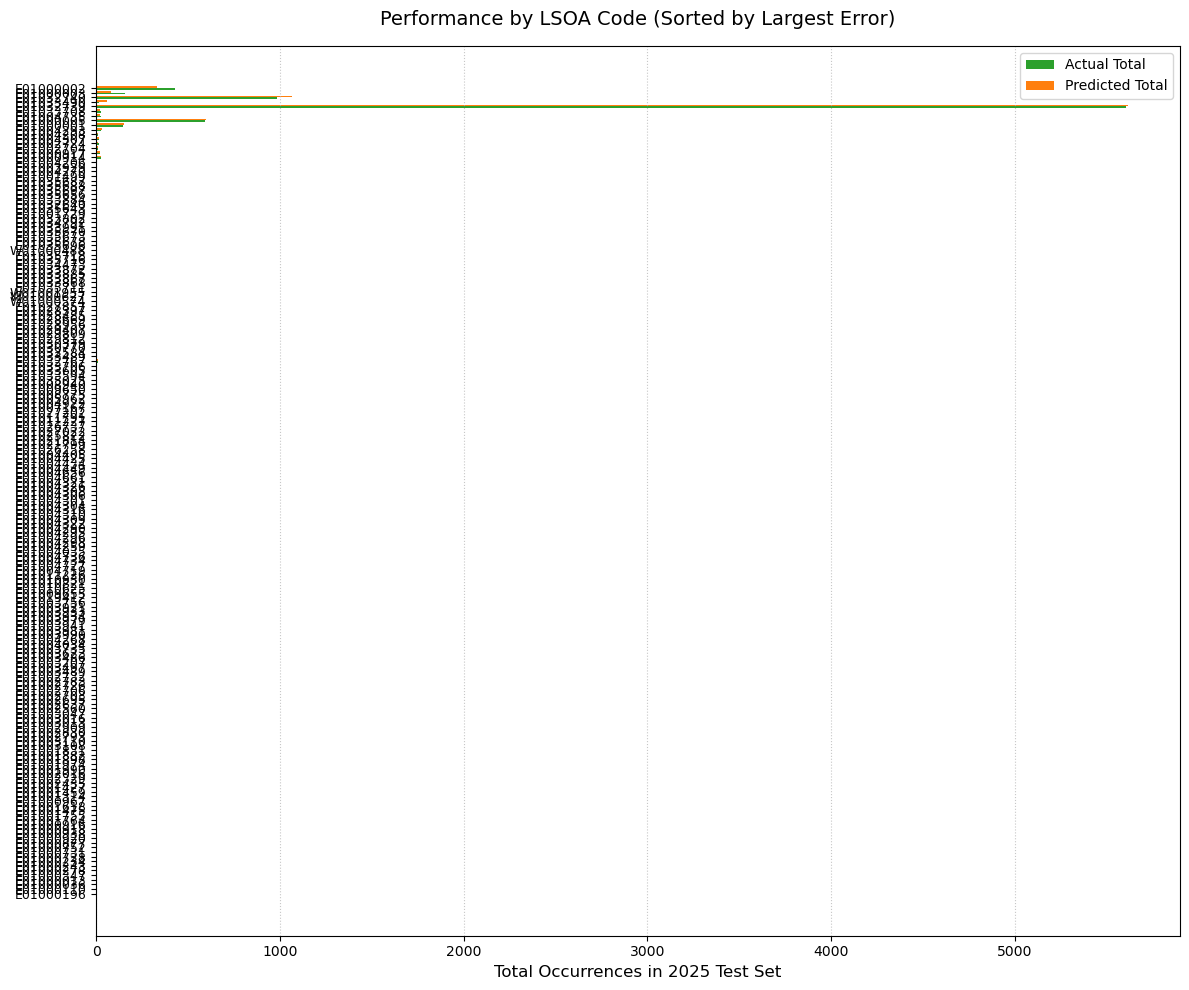

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Group the results by LSOA code and sum up the occurrences
lsoa_summary = results_df.groupby('LSOA code')[['Actual Occurrences', 'Predicted Occurrences']].sum()

# 2. Calculate the absolute error to see where the model was most "wrong"
lsoa_summary['Total Error'] = abs(lsoa_summary['Predicted Occurrences'] - lsoa_summary['Actual Occurrences'])

# 3. Sort by Total Error so the worst-performing areas are at the top
lsoa_summary = lsoa_summary.sort_values(by='Total Error', ascending=True)

# (Optional) If you have a massive amount of LSOA codes, uncomment the line below 
# to only show the top 25 areas where the model made the biggest mistakes
# lsoa_summary = lsoa_summary.tail(25)

# 4. Set up the plot
fig, ax = plt.subplots(figsize=(12, 10)) # Made it slightly taller for LSOA codes

y_pos = np.arange(len(lsoa_summary))
bar_height = 0.35

# Plot Actuals (Green) and Predicteds (Orange)
ax.barh(y_pos - bar_height/2, lsoa_summary['Actual Occurrences'], bar_height, label='Actual Total', color='#2ca02c')
ax.barh(y_pos + bar_height/2, lsoa_summary['Predicted Occurrences'], bar_height, label='Predicted Total', color='#ff7f0e')

# Formatting the axes and labels
ax.set_yticks(y_pos)
ax.set_yticklabels(lsoa_summary.index, fontsize=9)
ax.set_title('Performance by LSOA Code (Sorted by Largest Error)', fontsize=14, pad=15)
ax.set_xlabel('Total Occurrences in 2025 Test Set', fontsize=12)
ax.legend()
ax.grid(True, axis='x', linestyle=':', alpha=0.7)

# Adjust spacing and render
plt.tight_layout()
plt.show()

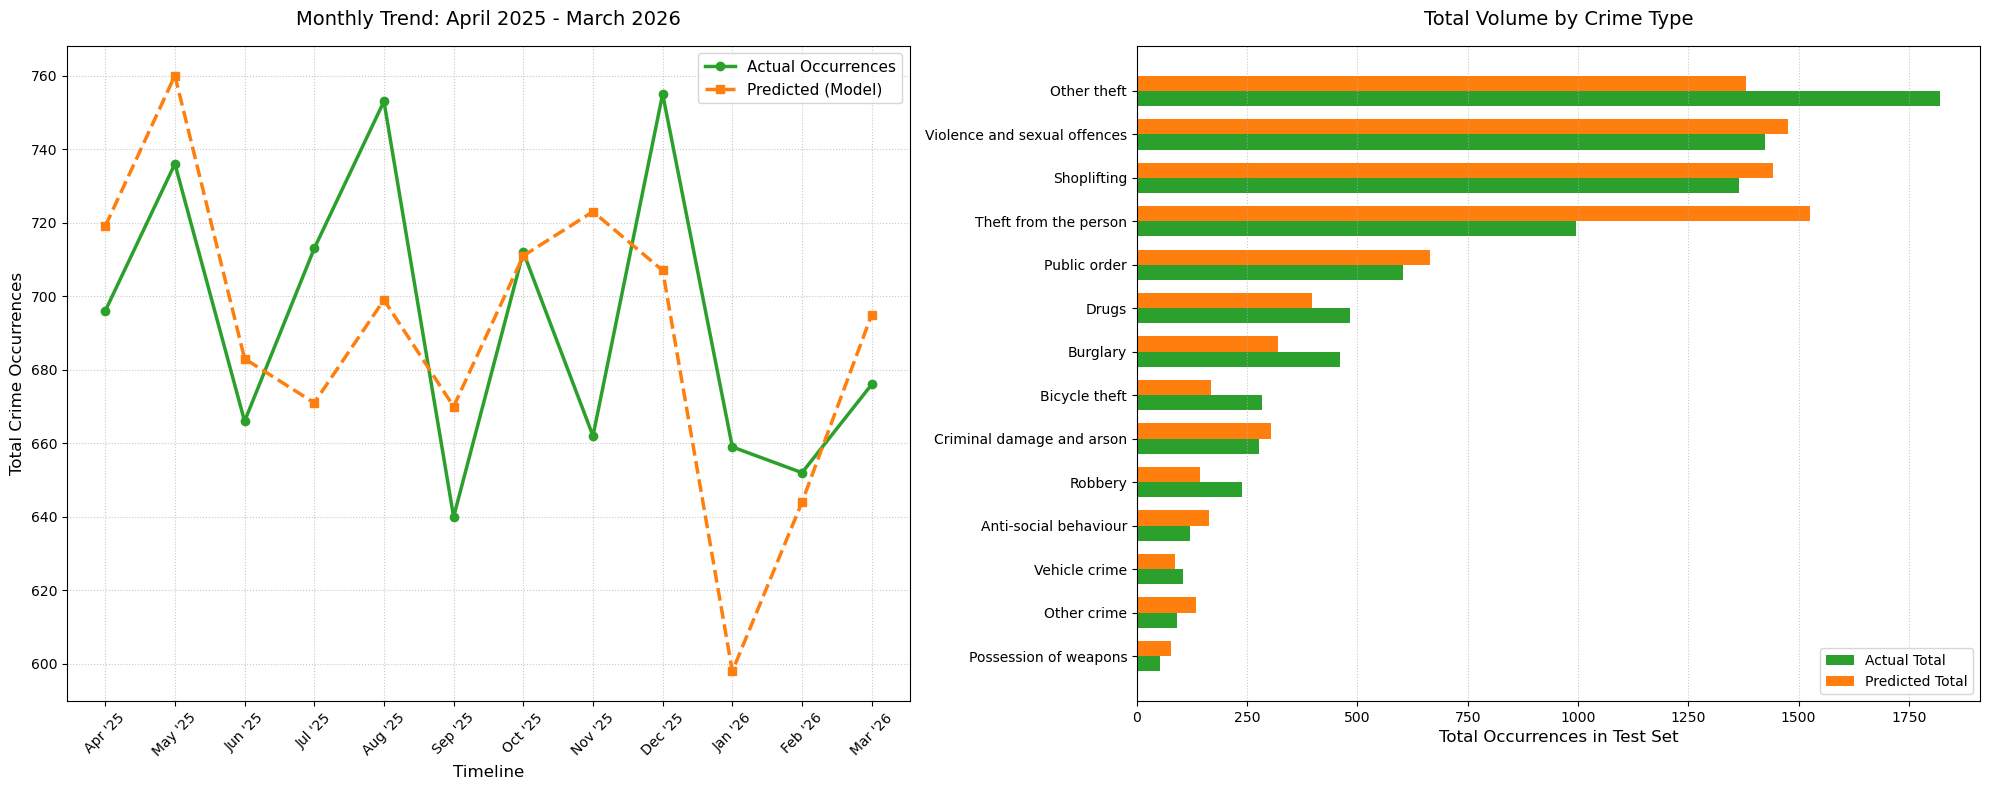

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Set up a wide figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# ==========================================
# Plot 1: Monthly Trend (Line Graph)
# ==========================================
# Group the results by Time_Index to keep chronological order
monthly_summary = results_df.groupby('Time_Index')[['Actual Occurrences', 'Predicted Occurrences']].sum().reset_index()
monthly_summary = monthly_summary.sort_values('Time_Index')

# Plot lines
ax1.plot(monthly_summary['Time_Index'], monthly_summary['Actual Occurrences'], 
        marker='o', linestyle='-', linewidth=2.5, color='#2ca02c', label='Actual Occurrences')
ax1.plot(monthly_summary['Time_Index'], monthly_summary['Predicted Occurrences'], 
        marker='s', linestyle='--', linewidth=2.5, color='#ff7f0e', label='Predicted (Model)')

# Formatting Plot 1
ax1.set_title('Monthly Trend: April 2025 - March 2026', fontsize=14, pad=15)
ax1.set_xlabel('Timeline', fontsize=12)
ax1.set_ylabel('Total Crime Occurrences', fontsize=12)

# Generate labels for X-axis
def get_month_label(t_idx):
    year = 2023 + (t_idx - 1) // 12
    month = (t_idx - 1) % 12 + 1
    month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 
                   7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
    return f"{month_names[month]} '{str(year)[-2:]}"

labels = [get_month_label(t) for t in monthly_summary['Time_Index']]
ax1.set_xticks(monthly_summary['Time_Index'])
ax1.set_xticklabels(labels, rotation=45) # Slight rotation so labels don't overlap
ax1.legend(fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.7)


# ==========================================
# Plot 2: Total Volume by Crime Type (Bar Chart)
# ==========================================
# Group results by Crime type
crime_summary = results_df.groupby('Crime type')[['Actual Occurrences', 'Predicted Occurrences']].sum()
crime_summary = crime_summary.sort_values(by='Actual Occurrences', ascending=True)

y_pos = np.arange(len(crime_summary))
bar_height = 0.35

# Plot horizontal bars
ax2.barh(y_pos - bar_height/2, crime_summary['Actual Occurrences'], bar_height, label='Actual Total', color='#2ca02c')
ax2.barh(y_pos + bar_height/2, crime_summary['Predicted Occurrences'], bar_height, label='Predicted Total', color='#ff7f0e')

# Formatting Plot 2
ax2.set_yticks(y_pos)
ax2.set_yticklabels(crime_summary.index, fontsize=10)
ax2.set_title('Total Volume by Crime Type', fontsize=14, pad=15)
ax2.set_xlabel('Total Occurrences in Test Set', fontsize=12)
ax2.legend()
ax2.grid(True, axis='x', linestyle=':', alpha=0.7)

# Adjust spacing so nothing gets cut off and render
plt.tight_layout()
plt.show()

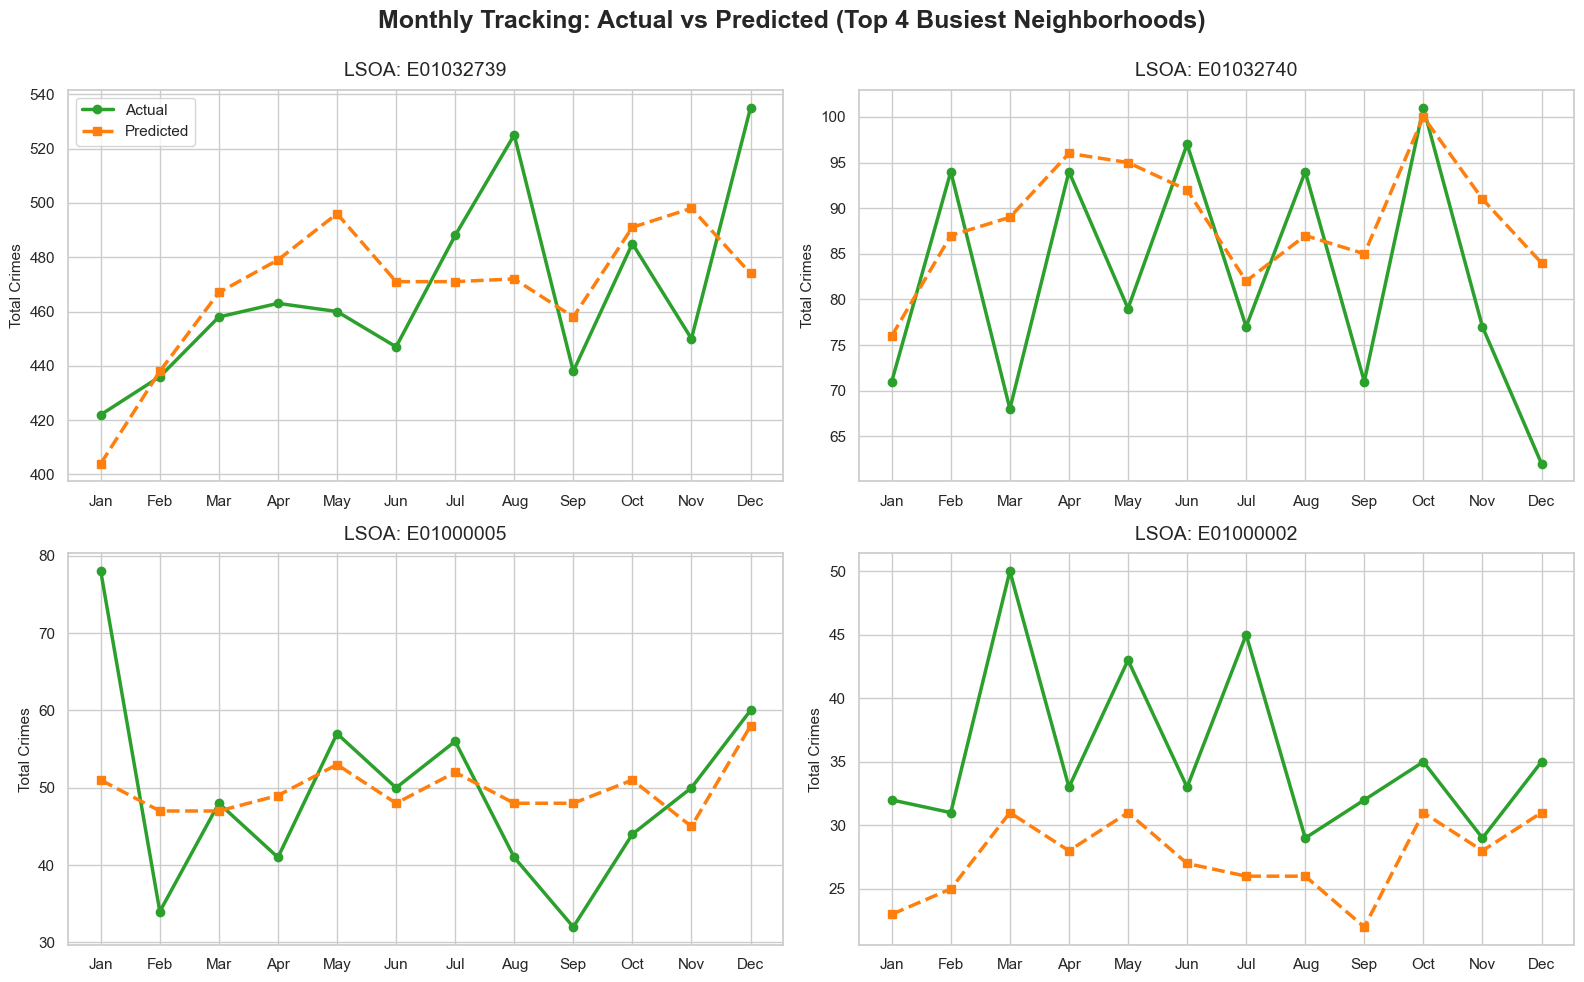

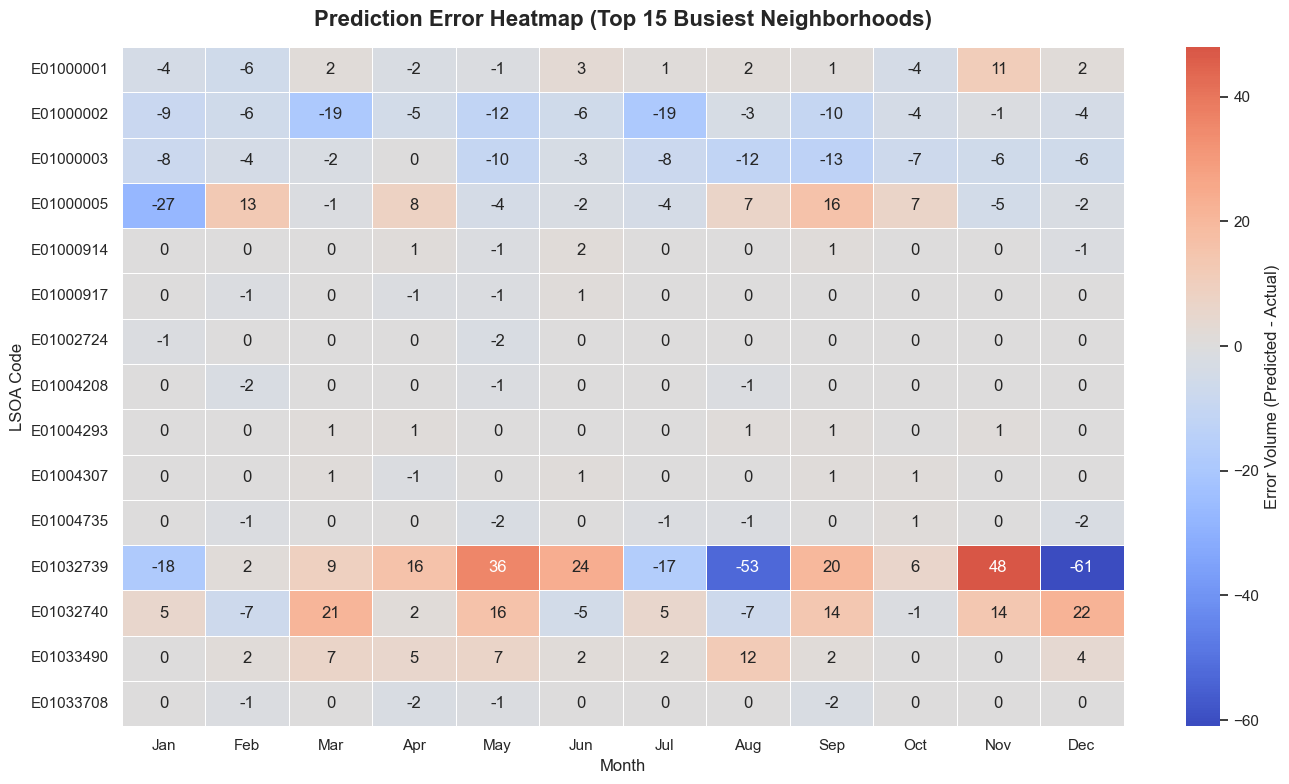

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set a professional presentation theme
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Define month names for our X-axis labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# ==============================================================================
# GRAPH 1: Deep Dive - Top 4 Busiest Neighborhoods (Month-by-Month Trend)
# ==============================================================================
# 1. Automatically find the top 4 LSOA codes by actual crime volume
# Using observed=True stops Pandas from doing math on neighborhoods that have 0 crimes
top_4_lsoa = results_df.groupby('LSOA code', observed=True)['Actual Occurrences'].sum().nlargest(4).index

# 2. Create a 2x2 grid of charts
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Monthly Tracking: Actual vs Predicted (Top 4 Busiest Neighborhoods)', fontsize=18, fontweight='bold', y=0.98)

for i, lsoa in enumerate(top_4_lsoa):
    # Determine the row and column in the 2x2 grid
    ax = axes[i//2, i%2]
    
    # Filter data for this specific LSOA and group by month
    lsoa_data = results_df[results_df['LSOA code'] == lsoa]
    monthly_lsoa = lsoa_data.groupby('Month_Num')[['Actual Occurrences', 'Predicted Occurrences']].sum().reindex(range(1, 13), fill_value=0).reset_index()
    
    # Plot Actuals (Green) and Predicteds (Orange)
    ax.plot(monthly_lsoa['Month_Num'], monthly_lsoa['Actual Occurrences'], marker='o', linewidth=2.5, color='#2ca02c', label='Actual')
    ax.plot(monthly_lsoa['Month_Num'], monthly_lsoa['Predicted Occurrences'], marker='s', linestyle='--', linewidth=2.5, color='#ff7f0e', label='Predicted')
    
    # Formatting
    ax.set_title(f'LSOA: {lsoa}', fontsize=14, pad=10)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_ylabel('Total Crimes', fontsize=11)
    
    # Only put the legend in the first chart to save space
    if i == 0:
        ax.legend(fontsize=11)

plt.tight_layout()
# Adjust top padding so the main title doesn't overlap the charts
fig.subplots_adjust(top=0.90) 
plt.show()

print("\n" + "="*80 + "\n")

# ==============================================================================
# GRAPH 2: Heatmap of Prediction Errors (Top 15 Neighborhoods x 12 Months)
# ==============================================================================
# 1. Grab the top 15 LSOA codes with the highest overall volume
top_15_lsoa = results_df.groupby('LSOA code', observed=True)['Actual Occurrences'].sum().nlargest(15).index

# 2. Filter data to just these 15 LSOA codes
heatmap_data_raw = results_df[results_df['LSOA code'].isin(top_15_lsoa)].copy()

# THE FIX: Convert LSOA code back to a string so Pandas forgets the other 100+ categories
heatmap_data_raw['LSOA code'] = heatmap_data_raw['LSOA code'].astype(str)

# 3. Create a pivot table: Rows = LSOA Code, Columns = Month_Num, Values = Difference
heatmap_df = heatmap_data_raw.groupby(['LSOA code', 'Month_Num'])['Difference'].sum().unstack(fill_value=0)

# 4. Rename the 1-12 columns to actual month names
heatmap_df.columns = [month_labels[m-1] for m in heatmap_df.columns if m <= 12]

# 5. Render the Heatmap
plt.figure(figsize=(14, 8))

# cmap="coolwarm" creates the perfect visual palette: 
# Red = Model over-predicted, Blue = Model under-predicted
ax_heat = sns.heatmap(heatmap_df, cmap='coolwarm', center=0, annot=True, fmt=".0f", 
                      linewidths=.5, cbar_kws={'label': 'Error Volume (Predicted - Actual)'})

plt.title('Prediction Error Heatmap (Top 15 Busiest Neighborhoods)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('LSOA Code', fontsize=12)

# Rotates the y-axis labels so they are easier to read
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

Total Actual:    8,320
Total Predicted: 8,280.0
Overall Bias:    -0.48%


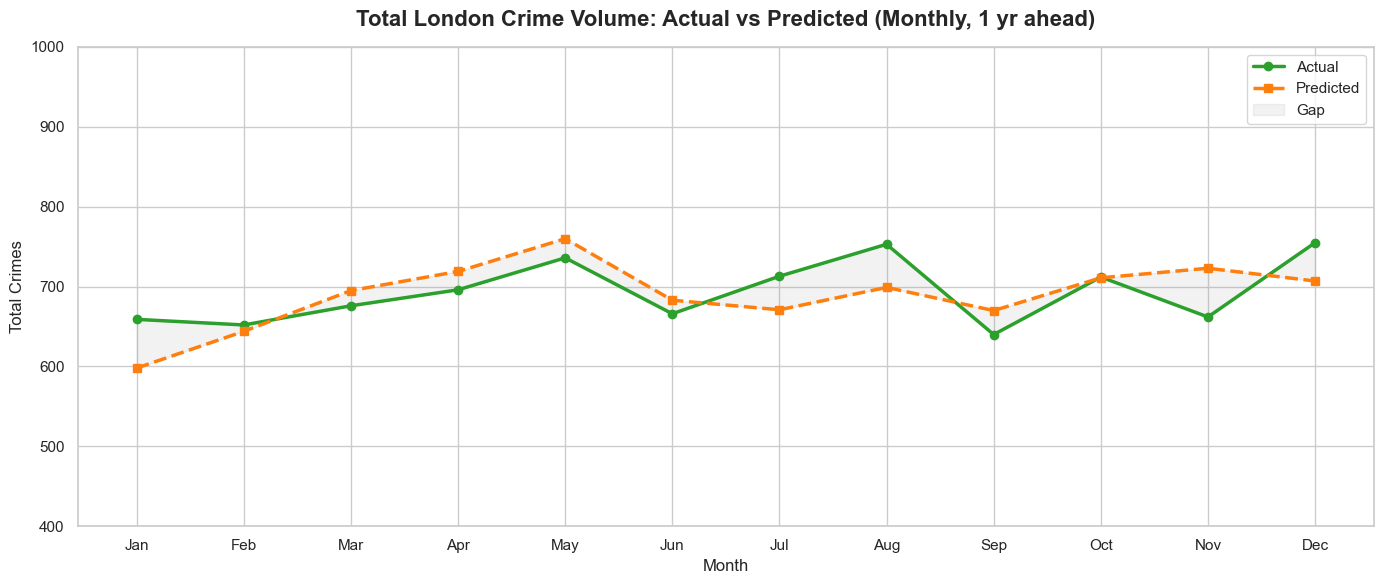

In [8]:
# --- Total London Crime Volume: Predicted vs Actual (Monthly) ---

monthly_totals = results_df.groupby('Month_Num')[['Actual Occurrences', 'Predicted Occurrences']].sum().reindex(range(1, 13), fill_value=0).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_totals['Month_Num'], monthly_totals['Actual Occurrences'], 
        marker='o', linewidth=2.5, color='#2ca02c', label='Actual')
ax.plot(monthly_totals['Month_Num'], monthly_totals['Predicted Occurrences'], 
        marker='s', linestyle='--', linewidth=2.5, color='#ff7f0e', label='Predicted')

ax.fill_between(monthly_totals['Month_Num'], 
                monthly_totals['Actual Occurrences'], 
                monthly_totals['Predicted Occurrences'], 
                alpha=0.1, color='gray', label='Gap')

ax.set_title('Total London Crime Volume: Actual vs Predicted (Monthly, 1 yr ahead)', fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_ylabel('Total Crimes', fontsize=12)
ax.set_xlabel('Month', fontsize=12)

# Set the y-axis limits from 400 to 1000
ax.set_ylim(400, 1000)

ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('london_crime_volume.png', dpi=300)

# Summary numbers below the plot
total_actual    = monthly_totals['Actual Occurrences'].sum()
total_predicted = monthly_totals['Predicted Occurrences'].sum()
overall_bias    = (total_predicted - total_actual) / total_actual * 100

print(f"Total Actual:    {total_actual:,}")
print(f"Total Predicted: {total_predicted:,}")
print(f"Overall Bias:    {overall_bias:+.2f}%")

In [9]:
print(test_df_raw['LSOA code'].nunique(), results_df['LSOA code'].nunique())

175 175


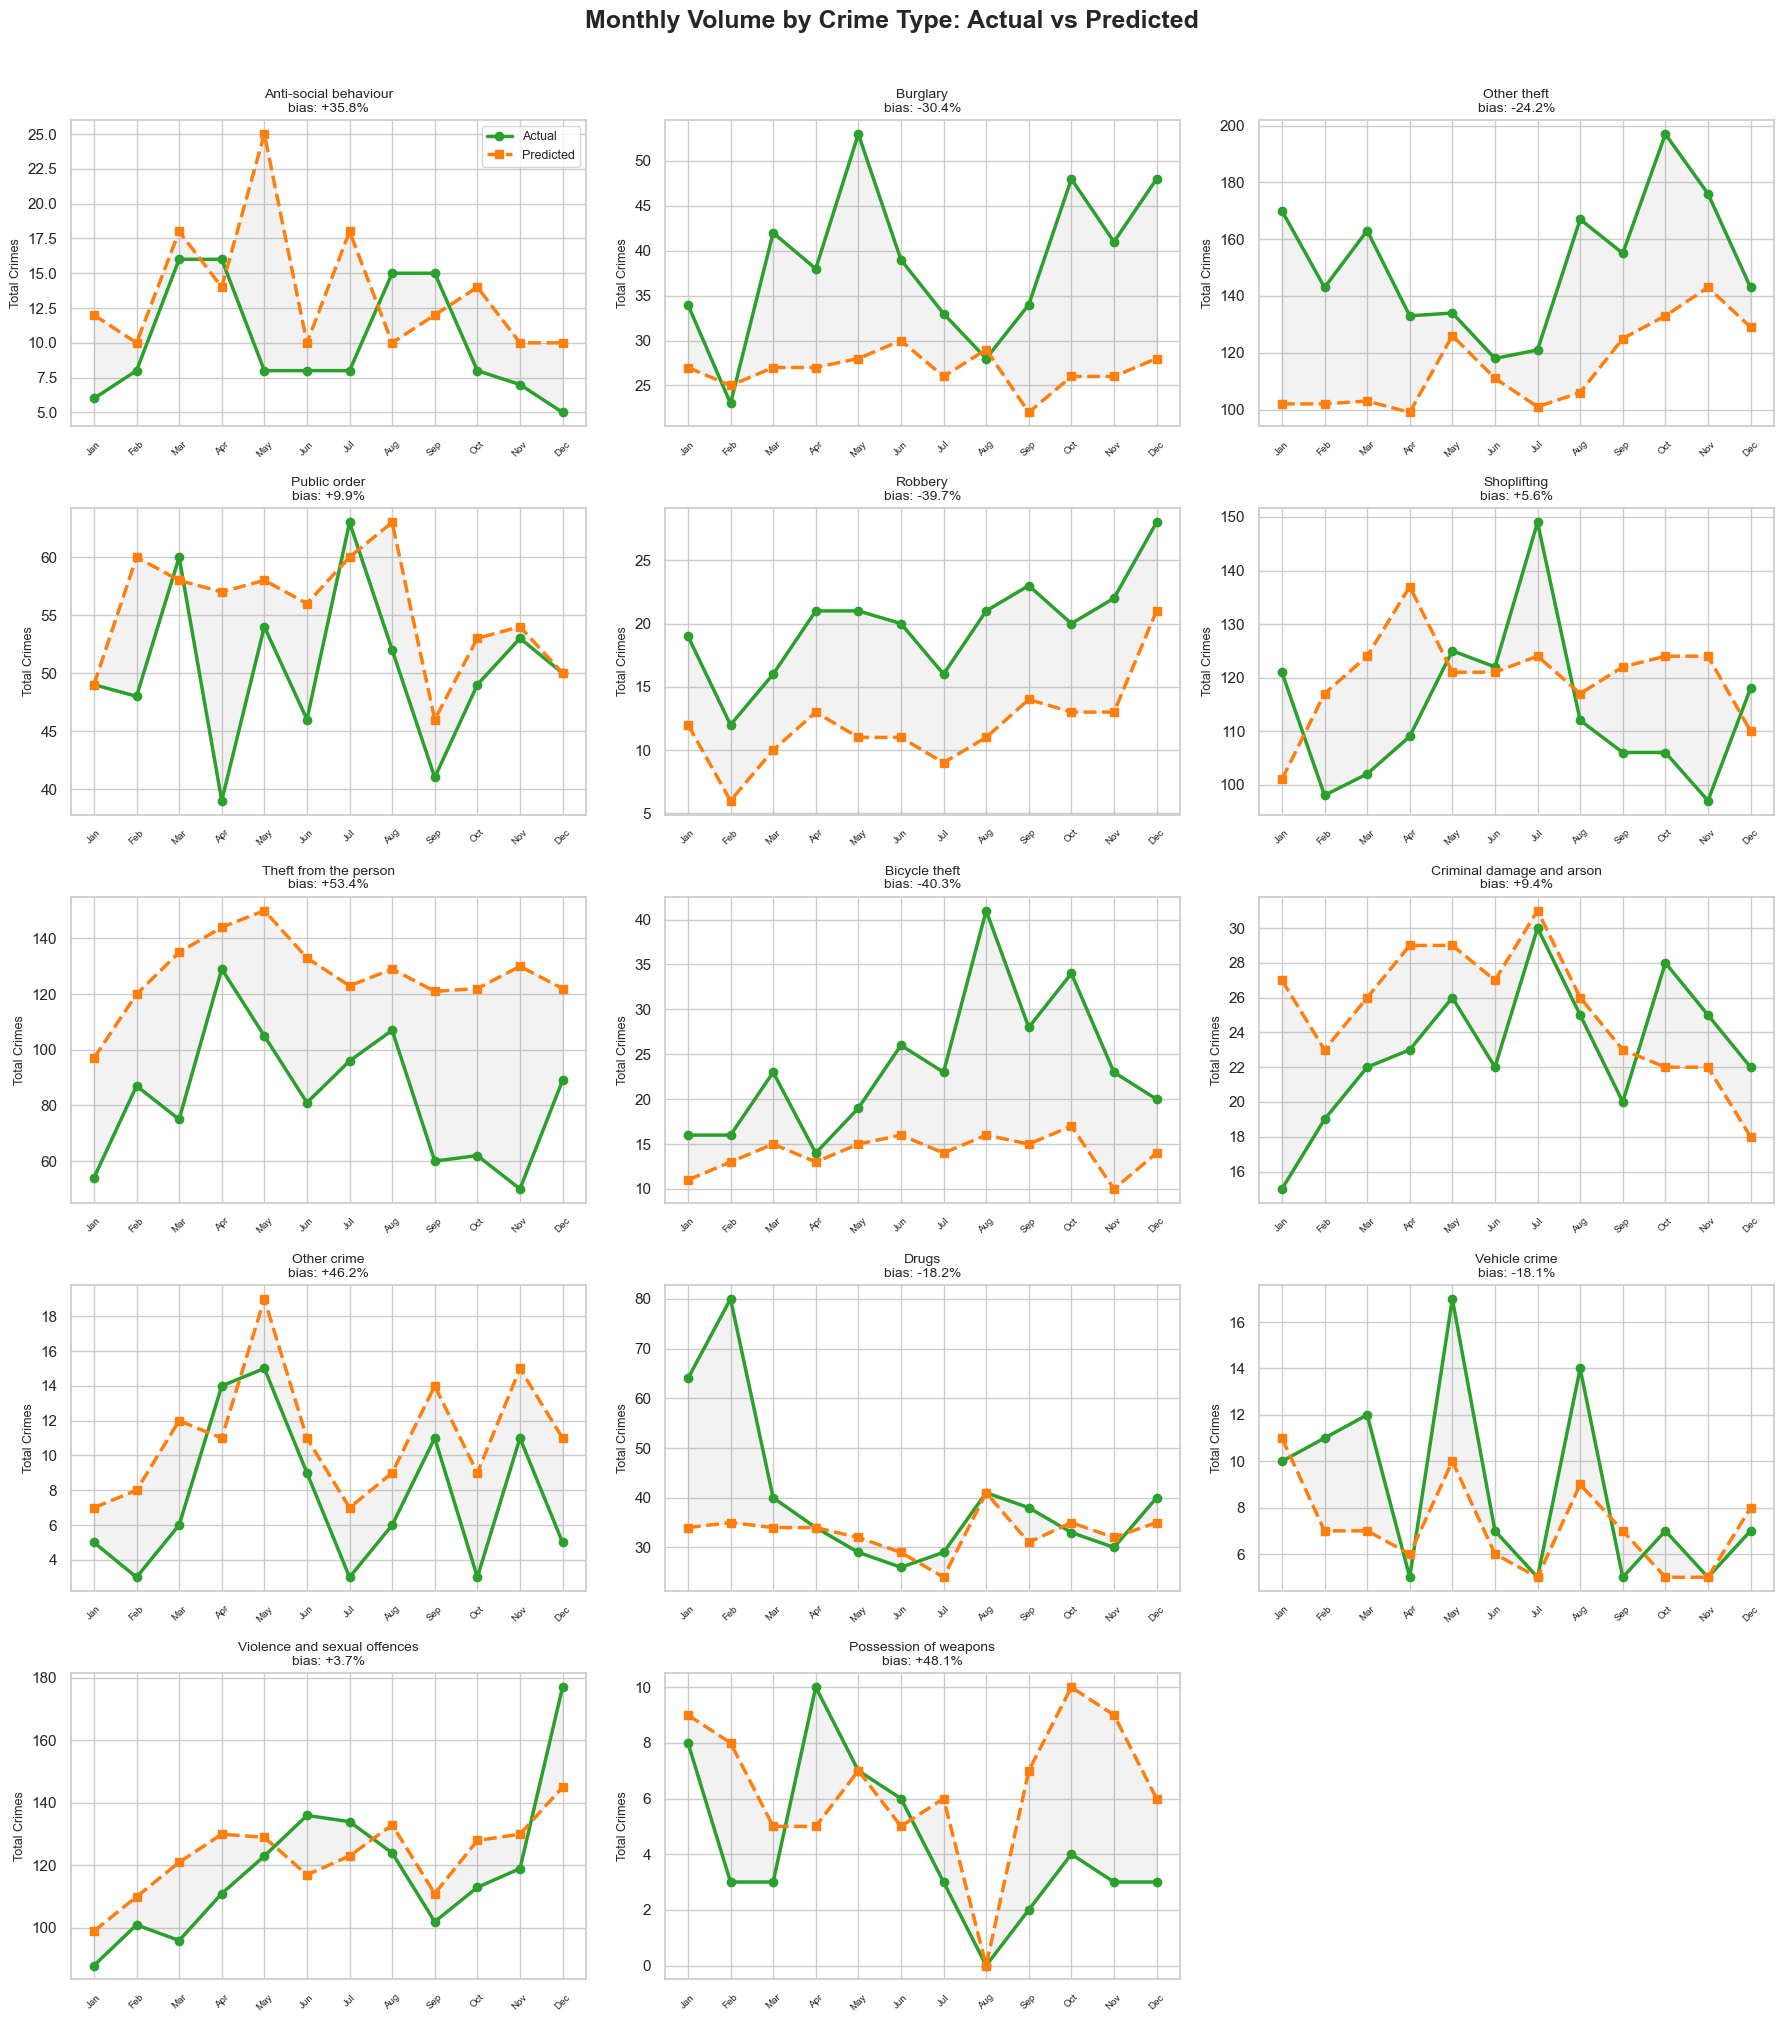

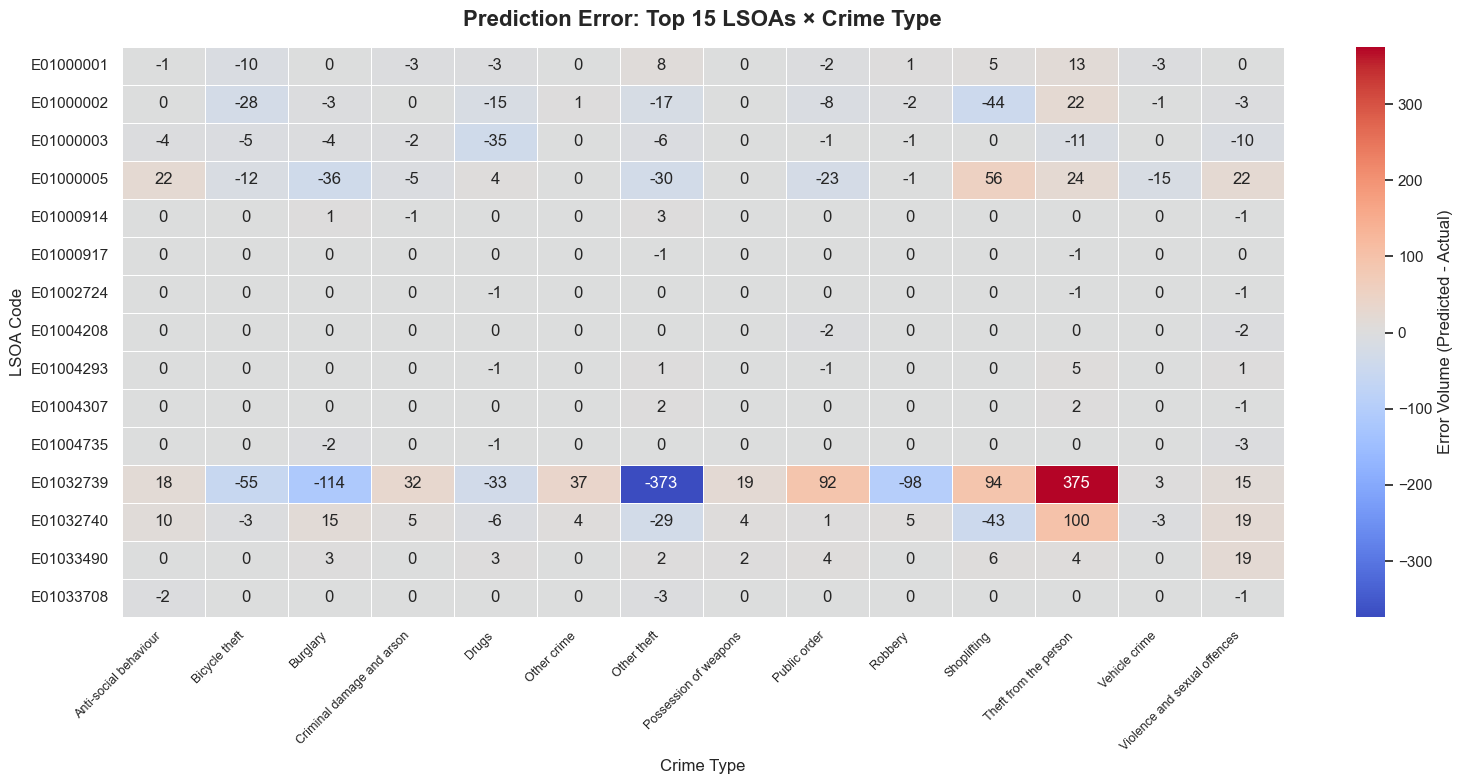

In [10]:
# --- Crime Type Performance: Total Volume + Heatmap per Crime Type ---


results_df['Crime type'] = results_df['Crime type'].astype(str)  # drop categorical
crime_types = results_df['Crime type'].unique().tolist()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# ==============================================================================
# GRAPH 1: Total Volume per Crime Type — Actual vs Predicted (one subplot each)
# ==============================================================================

n_crimes = len(crime_types)
ncols = 3
nrows = -(-n_crimes // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

fig.suptitle('Monthly Volume by Crime Type: Actual vs Predicted', 
             fontsize=18, fontweight='bold', y=1.01)

for i, crime in enumerate(crime_types):
    ax = axes[i]
    
    crime_data = results_df[results_df['Crime type'] == crime]
    monthly = (crime_data
               .groupby('Month_Num')[['Actual Occurrences', 'Predicted Occurrences']]
               .sum()
               .reindex(range(1, 13), fill_value=0)
               .reset_index())
    
    ax.plot(monthly['Month_Num'], monthly['Actual Occurrences'],
            marker='o', linewidth=2.5, color='#2ca02c', label='Actual')
    ax.plot(monthly['Month_Num'], monthly['Predicted Occurrences'],
            marker='s', linestyle='--', linewidth=2.5, color='#ff7f0e', label='Predicted')
    ax.fill_between(monthly['Month_Num'],
                    monthly['Actual Occurrences'],
                    monthly['Predicted Occurrences'],
                    alpha=0.1, color='gray')
    
    total_actual    = monthly['Actual Occurrences'].sum()
    total_predicted = monthly['Predicted Occurrences'].sum()
    bias_pct        = (total_predicted - total_actual) / total_actual * 100 if total_actual > 0 else 0
    
    ax.set_title(f'{crime}\nbias: {bias_pct:+.1f}%', fontsize=10, pad=6)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=7, rotation=45)
    ax.set_ylabel('Total Crimes', fontsize=9)
    if i == 0:
        ax.legend(fontsize=9)

# hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

print("\n" + "="*80 + "\n")

# ==============================================================================
# GRAPH 2: Heatmap — Top 15 Busiest LSOAs × Crime Type (prediction error)
# ==============================================================================

# top 15 LSOAs by total actual volume across all crime types
top_15_lsoa = (results_df
               .groupby('LSOA code', observed=True)['Actual Occurrences']
               .sum()
               .nlargest(15)
               .index)

heatmap_raw = results_df[results_df['LSOA code'].isin(top_15_lsoa)].copy()
heatmap_raw['LSOA code'] = heatmap_raw['LSOA code'].astype(str)

# pivot: rows = LSOA, columns = Crime type, values = total difference
heatmap_df = (heatmap_raw
              .groupby(['LSOA code', 'Crime type'], observed=True)['Difference']
              .sum()
              .unstack(fill_value=0))

plt.figure(figsize=(16, 8))

sns.heatmap(heatmap_df,
            cmap='coolwarm',
            center=0,
            annot=True,
            fmt='.0f',
            linewidths=.5,
            cbar_kws={'label': 'Error Volume (Predicted - Actual)'})

plt.title('Prediction Error: Top 15 LSOAs × Crime Type', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Crime Type', fontsize=12)
plt.ylabel('LSOA Code', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Evaluating 12 months: 2025-04 → 2026-03

2025-04 | Actual:    696 | Predicted:    753 | Bias:  +8.16%
2025-05 | Actual:    736 | Predicted:    740 | Bias:  +0.49%
2025-06 | Actual:    666 | Predicted:    675 | Bias:  +1.39%
2025-07 | Actual:    713 | Predicted:    657 | Bias:  -7.85%
2025-08 | Actual:    753 | Predicted:    723 | Bias:  -3.95%
2025-09 | Actual:    640 | Predicted:    733 | Bias: +14.50%
2025-10 | Actual:    712 | Predicted:    674 | Bias:  -5.38%
2025-11 | Actual:    662 | Predicted:    686 | Bias:  +3.69%
2025-12 | Actual:    755 | Predicted:    661 | Bias: -12.50%
2026-01 | Actual:    659 | Predicted:    661 | Bias:  +0.25%
2026-02 | Actual:    652 | Predicted:    671 | Bias:  +2.97%
2026-03 | Actual:    676 | Predicted:    704 | Bias:  +4.13%


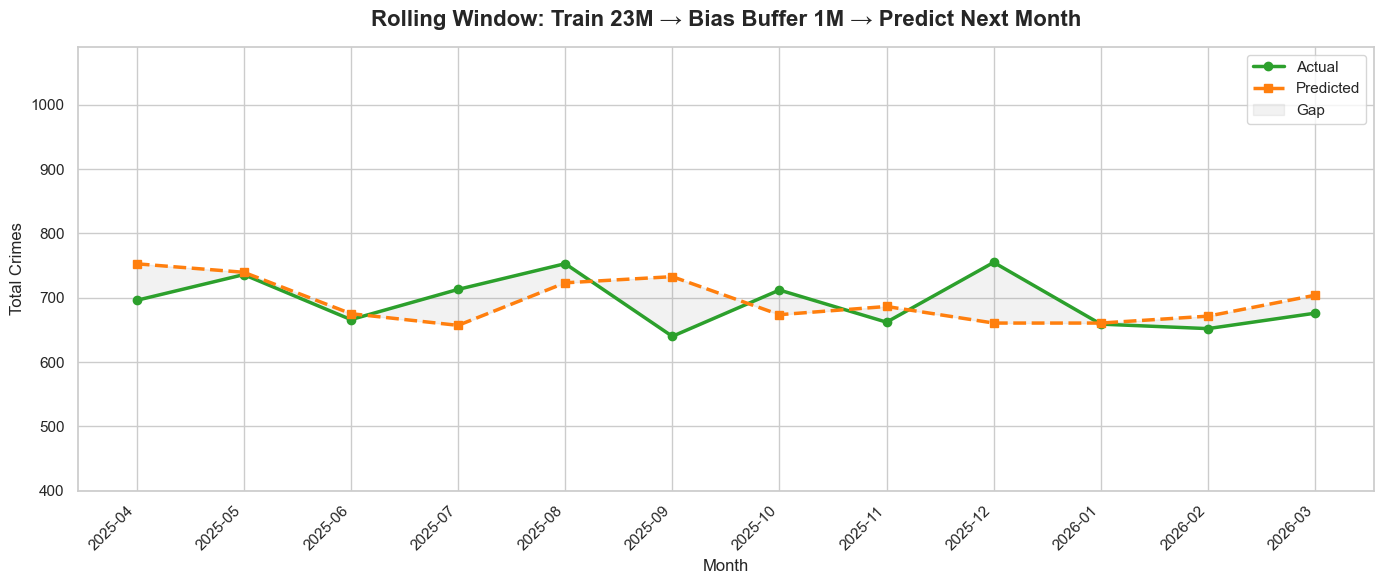


Total Actual:    8,320
Total Predicted: 8,337
Overall Bias:    +0.21%
MAE per month:   37.9 crimes


In [11]:
# --- Rolling Window Evaluation: Train 23 months, Bias Buffer 1 month, Predict Next ---

from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Full timeline
df_aggregated = pd.concat([train_df, test_df], ignore_index=True)
df_aggregated = prep_data(df_aggregated)
all_months    = sorted(df_aggregated['Month'].unique())

# Need 24 months before target (23 train + 1 bias buffer)
eval_months    = all_months[24:]
rolling_results = []

features   = ['Time_Index', 'Month_Num', 'LSOA code', 'Crime type']
cat_cols   = ['LSOA code', 'Crime type']
target_col = 'Number of occurrences'

print(f"Evaluating {len(eval_months)} months: {eval_months[0]} → {eval_months[-1]}\n")

for target_month in eval_months:
    target_idx = all_months.index(target_month)

    # ── Data slicing ──────────────────────────────────────────────
    months_for_training = all_months[target_idx - 24 : target_idx - 1]  # 23 months
    month_for_bias      = all_months[target_idx - 1]                     # 1 buffer month
    month_to_predict    = target_month                                    # prediction target

    df_train  = df_aggregated[df_aggregated['Month'].isin(months_for_training)].copy()
    df_bias   = df_aggregated[df_aggregated['Month'] == month_for_bias].copy()
    df_target = df_aggregated[df_aggregated['Month'] == month_to_predict].copy()

    # ── Top 5 split based on training window only ─────────────────
    top5_lsoas = (df_train.groupby('LSOA code')[target_col]
                  .sum().nlargest(5).index)

    df_train_top5   = df_train[df_train['LSOA code'].isin(top5_lsoas)]
    df_train_others = df_train[~df_train['LSOA code'].isin(top5_lsoas)]
    df_bias_top5    = df_bias[df_bias['LSOA code'].isin(top5_lsoas)]
    df_bias_others  = df_bias[~df_bias['LSOA code'].isin(top5_lsoas)]
    df_target_top5  = df_target[df_target['LSOA code'].isin(top5_lsoas)]
    df_target_others= df_target[~df_target['LSOA code'].isin(top5_lsoas)]

    # ── Feature matrices ──────────────────────────────────────────
    def make_X(df_source, df_reference=None):
        X = df_source[features].copy()
        for c in cat_cols:
            if df_reference is not None:
                X[c] = X[c].astype(df_reference[c].dtype)
            else:
                X[c] = X[c].astype('category')
        return X

    X_train_top5   = make_X(df_train_top5)
    X_train_others = make_X(df_train_others)
    X_bias_top5    = make_X(df_bias_top5,   df_reference=X_train_top5)
    X_bias_others  = make_X(df_bias_others, df_reference=X_train_others)
    X_target_top5  = make_X(df_target_top5,   df_reference=X_train_top5)
    X_target_others= make_X(df_target_others, df_reference=X_train_others)

    y_train_top5   = df_train_top5[target_col]
    y_train_others = df_train_others[target_col]
    y_bias_top5    = df_bias_top5[target_col]
    y_bias_others  = df_bias_others[target_col]
    y_target_top5  = df_target_top5[target_col]
    y_target_others= df_target_others[target_col]

    # ── Train ─────────────────────────────────────────────────────
    model_top5   = xgb.XGBRegressor(**xgb_params)
    model_others = xgb.XGBRegressor(**xgb_params)
    model_top5.fit(X_train_top5,   y_train_top5)
    model_others.fit(X_train_others, y_train_others)

    # ── Bias on buffer month (genuine out-of-sample) ──────────────
    pred_bias_top5   = model_top5.predict(X_bias_top5)
    pred_bias_others = model_others.predict(X_bias_others)

    bias_top5   = (pred_bias_top5.sum()   - y_bias_top5.sum())   / y_bias_top5.sum()   if y_bias_top5.sum()   > 0 else 0
    bias_others = (pred_bias_others.sum() - y_bias_others.sum()) / y_bias_others.sum() if y_bias_others.sum() > 0 else 0

    correction_top5   = 1 / (1 + bias_top5)
    correction_others = 1 / (1 + bias_others)

    # ── Predict target month with correction ──────────────────────
    pred_target_top5   = (model_top5.predict(X_target_top5)     * correction_top5).clip(min=0)
    pred_target_others = (model_others.predict(X_target_others) * correction_others).clip(min=0)

    # ── Collect results ───────────────────────────────────────────
    result_top5             = df_target_top5[['Month', 'LSOA code', 'Crime type', target_col]].copy()
    result_top5['Predicted Occurrences'] = pred_target_top5

    result_others             = df_target_others[['Month', 'LSOA code', 'Crime type', target_col]].copy()
    result_others['Predicted Occurrences'] = pred_target_others

    result_month = pd.concat([result_top5, result_others], ignore_index=True)
    result_month = result_month.rename(columns={target_col: 'Actual Occurrences'})
    result_month['Difference']   = result_month['Predicted Occurrences'] - result_month['Actual Occurrences']
    result_month['Target Month'] = target_month
    rolling_results.append(result_month)

    actual_vol = result_month['Actual Occurrences'].sum()
    pred_vol   = result_month['Predicted Occurrences'].sum()
    bias_pct   = (pred_vol - actual_vol) / actual_vol * 100
    print(f"{target_month} | Actual: {actual_vol:>6.0f} | Predicted: {pred_vol:>6.0f} | Bias: {bias_pct:>+6.2f}%")

# ── Combine all months ────────────────────────────────────────────
rolling_df = pd.concat(rolling_results, ignore_index=True)

# ── Plot ──────────────────────────────────────────────────────────
monthly_roll = (rolling_df
                .groupby('Target Month')[['Actual Occurrences', 'Predicted Occurrences']]
                .sum().reset_index())

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_roll['Target Month'], monthly_roll['Actual Occurrences'],
        marker='o', linewidth=2.5, color='#2ca02c', label='Actual')
ax.plot(monthly_roll['Target Month'], monthly_roll['Predicted Occurrences'],
        marker='s', linestyle='--', linewidth=2.5, color='#ff7f0e', label='Predicted')
ax.fill_between(range(len(monthly_roll)),
                monthly_roll['Actual Occurrences'],
                monthly_roll['Predicted Occurrences'],
                alpha=0.1, color='gray', label='Gap')

ax.set_title('Rolling Window: Train 23M → Bias Buffer 1M → Predict Next Month',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(range(len(monthly_roll)))
ax.set_xticklabels(monthly_roll['Target Month'], rotation=45, ha='right')
ax.set_ylim(400, 1090)
ax.set_ylabel('Total Crimes', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────
total_actual    = monthly_roll['Actual Occurrences'].sum()
total_predicted = monthly_roll['Predicted Occurrences'].sum()
overall_bias    = (total_predicted - total_actual) / total_actual * 100
mae             = mean_absolute_error(monthly_roll['Actual Occurrences'],
                                      monthly_roll['Predicted Occurrences'])

print(f"\nTotal Actual:    {total_actual:,.0f}")
print(f"Total Predicted: {total_predicted:,.0f}")
print(f"Overall Bias:    {overall_bias:+.2f}%")
print(f"MAE per month:   {mae:,.1f} crimes")

In [13]:
print(train_df.columns.tolist())
print(test_df.columns.tolist())

['Month', 'LSOA code', 'Crime type', 'Number of occurrences']
['Month', 'LSOA code', 'Crime type', 'Number of occurrences']


Evaluating 10 months: 2025-06 → 2026-03

2025-06 | Actual:    666 | Predicted:    675 | Bias:  +1.28%
2025-07 | Actual:    713 | Predicted:    630 | Bias: -11.58%
2025-08 | Actual:    753 | Predicted:    691 | Bias:  -8.24%
2025-09 | Actual:    640 | Predicted:    684 | Bias:  +6.81%
2025-10 | Actual:    712 | Predicted:    768 | Bias:  +7.92%
2025-11 | Actual:    662 | Predicted:    721 | Bias:  +8.95%
2025-12 | Actual:    755 | Predicted:    673 | Bias: -10.88%
2026-01 | Actual:    659 | Predicted:    627 | Bias:  -4.87%
2026-02 | Actual:    652 | Predicted:    672 | Bias:  +3.10%
2026-03 | Actual:    676 | Predicted:    727 | Bias:  +7.49%


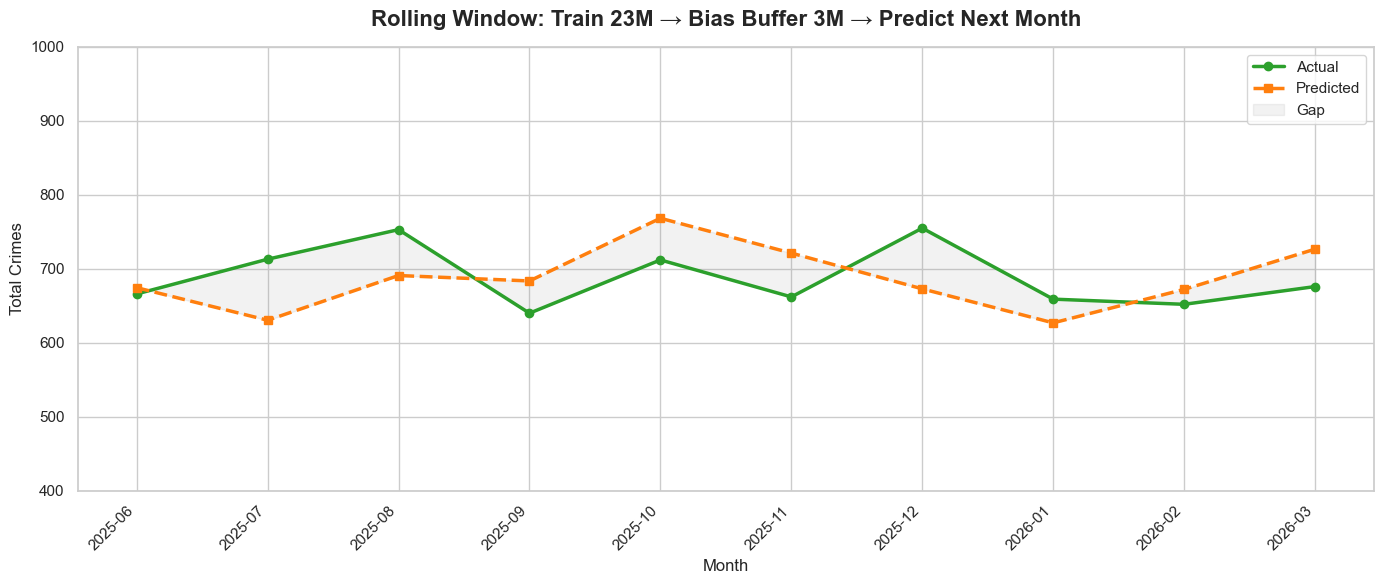


Total Actual:    6,888
Total Predicted: 6,868
Overall Bias:    -0.29%
MAE per month:   49.7 crimes


In [14]:
# --- Rolling Window Evaluation: Train 23 months, Bias Buffer 3 month, Predict Next ---

from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Full timeline
df_aggregated = pd.concat([train_df, test_df], ignore_index=True)
df_aggregated = prep_data(df_aggregated)
all_months    = sorted(df_aggregated['Month'].unique())

# Need 26 months before target (23 train + 3 bias buffer)
eval_months    = all_months[26:]
rolling_results = []

features   = ['Time_Index', 'Month_Num', 'LSOA code', 'Crime type']
cat_cols   = ['LSOA code', 'Crime type']
target_col = 'Number of occurrences'

print(f"Evaluating {len(eval_months)} months: {eval_months[0]} → {eval_months[-1]}\n")

for target_month in eval_months:
    target_idx = all_months.index(target_month)

    # ── Data slicing ──────────────────────────────────────────────
    months_for_training = all_months[target_idx - 26 : target_idx - 3]  # 23 months
    months_for_bias     = all_months[target_idx - 3  : target_idx]      # 3 buffer months
    month_to_predict    = target_month                                  # prediction target

    df_train  = df_aggregated[df_aggregated['Month'].isin(months_for_training)].copy()
    df_bias   = df_aggregated[df_aggregated['Month'].isin(months_for_bias)].copy()
    df_target = df_aggregated[df_aggregated['Month'] == month_to_predict].copy()

    # ── Top 5 split based on training window only ─────────────────
    top5_lsoas = (df_train.groupby('LSOA code')[target_col]
                  .sum().nlargest(5).index)

    df_train_top5   = df_train[df_train['LSOA code'].isin(top5_lsoas)]
    df_train_others = df_train[~df_train['LSOA code'].isin(top5_lsoas)]
    df_bias_top5    = df_bias[df_bias['LSOA code'].isin(top5_lsoas)]
    df_bias_others  = df_bias[~df_bias['LSOA code'].isin(top5_lsoas)]
    df_target_top5  = df_target[df_target['LSOA code'].isin(top5_lsoas)]
    df_target_others= df_target[~df_target['LSOA code'].isin(top5_lsoas)]

    # ── Feature matrices ──────────────────────────────────────────
    def make_X(df_source, df_reference=None):
        X = df_source[features].copy()
        for c in cat_cols:
            if df_reference is not None:
                X[c] = X[c].astype(df_reference[c].dtype)
            else:
                X[c] = X[c].astype('category')
        return X

    X_train_top5   = make_X(df_train_top5)
    X_train_others = make_X(df_train_others)
    X_bias_top5    = make_X(df_bias_top5,   df_reference=X_train_top5)
    X_bias_others  = make_X(df_bias_others, df_reference=X_train_others)
    X_target_top5  = make_X(df_target_top5,   df_reference=X_train_top5)
    X_target_others= make_X(df_target_others, df_reference=X_train_others)

    y_train_top5   = df_train_top5[target_col]
    y_train_others = df_train_others[target_col]
    y_bias_top5    = df_bias_top5[target_col]
    y_bias_others  = df_bias_others[target_col]
    y_target_top5  = df_target_top5[target_col]
    y_target_others= df_target_others[target_col]

    # ── Train ─────────────────────────────────────────────────────
    model_top5   = xgb.XGBRegressor(**xgb_params)
    model_others = xgb.XGBRegressor(**xgb_params)
    model_top5.fit(X_train_top5,   y_train_top5)
    model_others.fit(X_train_others, y_train_others)

    # ── Bias on buffer month (genuine out-of-sample) ──────────────
    pred_bias_top5   = model_top5.predict(X_bias_top5)
    pred_bias_others = model_others.predict(X_bias_others)

    bias_top5   = (pred_bias_top5.sum()   - y_bias_top5.sum())   / y_bias_top5.sum()   if y_bias_top5.sum()   > 0 else 0
    bias_others = (pred_bias_others.sum() - y_bias_others.sum()) / y_bias_others.sum() if y_bias_others.sum() > 0 else 0

    correction_top5   = 1 / (1 + bias_top5)
    correction_others = 1 / (1 + bias_others)

    # ── Predict target month with correction ──────────────────────
    pred_target_top5   = (model_top5.predict(X_target_top5)     * correction_top5).clip(min=0)
    pred_target_others = (model_others.predict(X_target_others) * correction_others).clip(min=0)

    # ── Collect results ───────────────────────────────────────────
    result_top5             = df_target_top5[['Month', 'LSOA code', 'Crime type', target_col]].copy()
    result_top5['Predicted Occurrences'] = pred_target_top5

    result_others             = df_target_others[['Month', 'LSOA code', 'Crime type', target_col]].copy()
    result_others['Predicted Occurrences'] = pred_target_others

    result_month = pd.concat([result_top5, result_others], ignore_index=True)
    result_month = result_month.rename(columns={target_col: 'Actual Occurrences'})
    result_month['Difference']   = result_month['Predicted Occurrences'] - result_month['Actual Occurrences']
    result_month['Target Month'] = target_month
    rolling_results.append(result_month)

    actual_vol = result_month['Actual Occurrences'].sum()
    pred_vol   = result_month['Predicted Occurrences'].sum()
    bias_pct   = (pred_vol - actual_vol) / actual_vol * 100
    print(f"{target_month} | Actual: {actual_vol:>6.0f} | Predicted: {pred_vol:>6.0f} | Bias: {bias_pct:>+6.2f}%")

# ── Combine all months ────────────────────────────────────────────
rolling_df = pd.concat(rolling_results, ignore_index=True)

# ── Plot ──────────────────────────────────────────────────────────
monthly_roll = (rolling_df
                .groupby('Target Month')[['Actual Occurrences', 'Predicted Occurrences']]
                .sum().reset_index())

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_roll['Target Month'], monthly_roll['Actual Occurrences'],
        marker='o', linewidth=2.5, color='#2ca02c', label='Actual')
ax.plot(monthly_roll['Target Month'], monthly_roll['Predicted Occurrences'],
        marker='s', linestyle='--', linewidth=2.5, color='#ff7f0e', label='Predicted')
ax.fill_between(range(len(monthly_roll)),
                monthly_roll['Actual Occurrences'],
                monthly_roll['Predicted Occurrences'],
                alpha=0.1, color='gray', label='Gap')

ax.set_title('Rolling Window: Train 23M → Bias Buffer 3M → Predict Next Month',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(range(len(monthly_roll)))
ax.set_xticklabels(monthly_roll['Target Month'], rotation=45, ha='right')
ax.set_ylim(400, 1000)
ax.set_ylabel('Total Crimes', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────
total_actual    = monthly_roll['Actual Occurrences'].sum()
total_predicted = monthly_roll['Predicted Occurrences'].sum()
overall_bias    = (total_predicted - total_actual) / total_actual * 100
mae              = mean_absolute_error(monthly_roll['Actual Occurrences'],
                                      monthly_roll['Predicted Occurrences'])

print(f"\nTotal Actual:    {total_actual:,.0f}")
print(f"Total Predicted: {total_predicted:,.0f}")
print(f"Overall Bias:    {overall_bias:+.2f}%")
print(f"MAE per month:   {mae:,.1f} crimes")